# **Experiments on My MAMBA Model**

**IMPORTS**

In [6]:
import torch
import os, sys, time, copy, pickle as pkl
import pandas as pd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('dark')
%matplotlib inline
from model.parallel_scan import pscan
torch.manual_seed(0)

**COMPARING SEQUENTIAL AND PARALLEL IMPLEMENTATION OF SELECTIVE SCAN**

In [7]:
# Dummy Problem
B, L, D, N = 2, 16, 4, 3
A = torch.rand(B, L, D, N, requires_grad=True)
X = torch.rand(B, L, D, N, requires_grad=True)

# Parallel implementation
Y_par = pscan(A, X)
loss_par = Y_par.sum()
loss_par.backward()
gradA_par = A.grad.clone()
gradX_par = X.grad.clone()

# Sequential implementation
A_seq = A.detach().clone().requires_grad_(True)
X_seq = X.detach().clone().requires_grad_(True)
state = torch.zeros(B, D, N)
outputs = []
for t in range(L):
    state = A_seq[:, t] * state + X_seq[:, t]
    outputs.append(state)
Y_seq = torch.stack(outputs, dim=1)
loss_seq = Y_seq.sum()
loss_seq.backward()
gradA_seq = A_seq.grad
gradX_seq = X_seq.grad

# Forward check
forward_diff = (Y_par - Y_seq).abs()
print("Forward:")
print(f"  max abs error  = {forward_diff.max().item():.3e}")
print(f"  mean abs error = {forward_diff.mean().item():.3e}")

# Gradient check: A
gradA_diff = (gradA_par - gradA_seq).abs()
print("\nGradient w.r.t. A:")
print(f"  max abs error  = {gradA_diff.max().item():.3e}")
print(f"  mean abs error = {gradA_diff.mean().item():.3e}")
# Gradient check: X
gradX_diff = (gradX_par - gradX_seq).abs()

print("\nGradient w.r.t. X:")
print(f"  max abs error  = {gradX_diff.max().item():.3e}")
print(f"  mean abs error = {gradX_diff.mean().item():.3e}")

# Overall
tol = 1e-6

print("\nChecks:")
print("  Forward :", torch.allclose(Y_par, Y_seq, atol=tol, rtol=tol))
print("  Grad A  :", torch.allclose(gradA_par, gradA_seq, atol=tol, rtol=tol))
print("  Grad X  :", torch.allclose(gradX_par, gradX_seq, atol=tol, rtol=tol))

Forward:
  max abs error  = 2.384e-07
  mean abs error = 2.291e-08

Gradient w.r.t. A:
  max abs error  = 4.768e-07
  mean abs error = 5.545e-08

Gradient w.r.t. X:
  max abs error  = 4.768e-07
  mean abs error = 3.943e-08

Checks:
  Forward : True
  Grad A  : True
  Grad X  : True


**PLOTTING TRAINING AND VALIDATION CURVES**

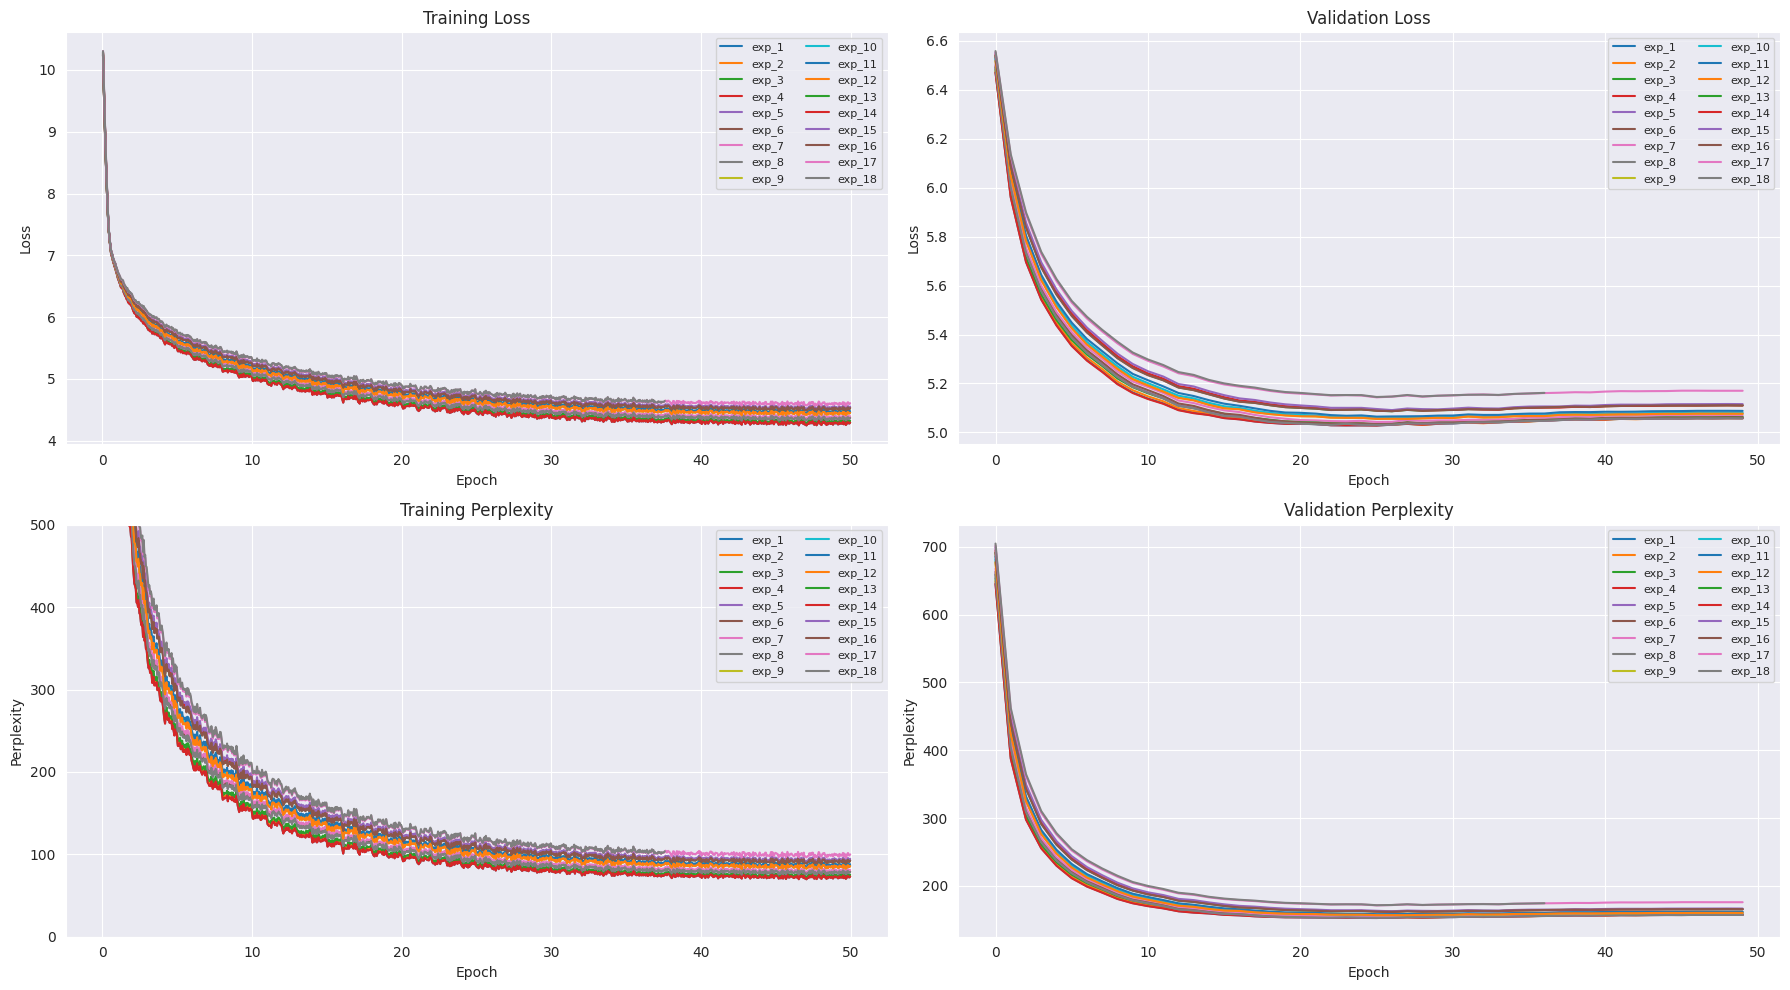

In [8]:
train_data = {}
val_data = {}
for i in range(1, 19):
    if i<10:
        train_path = f"logs/exp_000{i}.log_train.csv"
        val_path   = f"logs/exp_000{i}.log_val.csv"
    else:
        train_path = f"logs/exp_00{i}.log_train.csv"
        val_path   = f"logs/exp_00{i}.log_val.csv"
    
    train_data[i] = pd.read_csv(train_path)
    val_data[i] = pd.read_csv(val_path)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# ---------------- TRAIN LOSS ----------------
for i in range(1, 19):
    axes[0, 0].plot(train_data[i]["epoch"], train_data[i]["loss"], label=f"exp_{i}")

axes[0, 0].set_title("Training Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].grid(True)

# ---------------- VAL LOSS ----------------
for i in range(1, 19):
    axes[0, 1].plot(val_data[i]["epoch"], val_data[i]["loss"], label=f"exp_{i}")

axes[0, 1].set_title("Validation Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].grid(True)

# ---------------- TRAIN PPL ----------------
for i in range(1, 19):
    axes[1, 0].plot(train_data[i]["epoch"], train_data[i]["ppl"], label=f"exp_{i}")

axes[1, 0].set_title("Training Perplexity")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Perplexity")
axes[1, 0].set_ylim(0, 500)
axes[1, 0].grid(True)

# ---------------- VAL PPL ----------------
for i in range(1, 19):
    axes[1, 1].plot(val_data[i]["epoch"], val_data[i]["ppl"], label=f"exp_{i}")

axes[1, 1].set_title("Validation Perplexity")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Perplexity")
axes[1, 1].grid(True)

# Add legends (once per subplot)
for ax in axes.flat:
    ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()